In [9]:
"""Calculate the average daily spread (max - min) of day-ahead electricity prices."""

import pandas as pd
from sklearn.linear_model import LinearRegression

years = [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

CSV_PATH = "datasets/energy-charts_Electricity_production_and_spot_prices_in_Switzerland_in_2025.csv"
PRICE_COL = "Day Ahead Auction (CH)"

# now load multiple CSVs
CSV_PATHS = [f"datasets/spot/energy-charts_Electricity_production_and_spot_prices_in_Switzerland_in_{year}.csv" for year in years]

# CKW dataset (hourly end-user prices, CHF/kWh).
CKW_CSV_PATH = "datasets/ckw_dynamic_home_tariff_hourly.csv"
CKW_PRICE_COL = "integrated"  # total end price

# EKZ dataset (hourly dynamic tariff, CHF/kWh). Timestamps already Swiss-local.
EKZ_CSV_PATH = "ekz_dynamic_2026_hourly.csv"
EKZ_PRICE_COL = "avg_price_chf_kwh"

# CO2 carbon intensity dataset (hourly, Switzerland 2025).
CO2_CSV_PATH = "datasets/snapshots_2026-02-10_CH-2025-hourly.csv"
CO2_COLS = {
    "direct": "Carbon intensity gCO\u2082eq/kWh (direct)",
    "life cycle": "Carbon intensity gCO\u2082eq/kWh (Life cycle)",
}

# 1. Spot Price Data

In [10]:
df_list = []
for path in CSV_PATHS:
    df = pd.read_csv(path, skiprows=[1])
    df_list.append(df)
df = pd.concat(df_list, ignore_index=True)

# # Load CSV. Row 0 is the column names, row 1 is units -> skip the units row.
# df = pd.read_csv(CSV_PATH, skiprows=[1])

# Parse timestamps (ISO 8601 with timezone offset).
# utc=True handles the daylight-saving offset change (+01:00 / +02:00),
# then convert to local Swiss time so hour-of-day matches the wall clock.
ts = pd.to_datetime(df["Date (GMT+1)"], utc=True)
df["Date (GMT+1)"] = ts.dt.tz_convert("Europe/Zurich")
df["day"] = df["Date (GMT+1)"].dt.date
df["hour"] = df["Date (GMT+1)"].dt.hour

# Ensure price is numeric and drop rows without a price.
df[PRICE_COL] = pd.to_numeric(df[PRICE_COL], errors="coerce")
df = df.dropna(subset=[PRICE_COL])

# --- Daily spread: max - min over each calendar day, averaged. ---
daily_spread = df.groupby("day")[PRICE_COL].agg(lambda s: s.max() - s.min())
avg_spread = daily_spread.mean()

Spread increase 2015->2025: 230.3%
Trend slope: 7.18 EUR/MWh per year


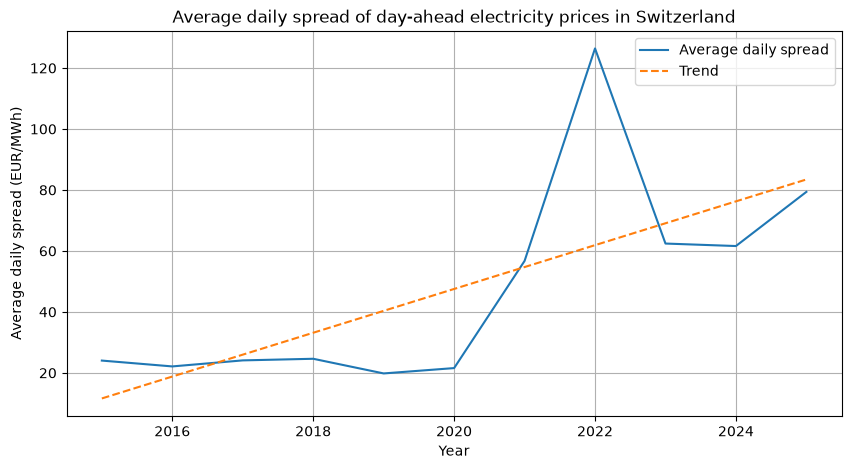

In [11]:
df["year"] = df["Date (GMT+1)"].dt.year
daily = df.groupby(["year", "day"])[PRICE_COL].agg(lambda s: s.max() - s.min())
yearly_spread = daily.groupby(level="year").mean()    # 2. fit linear regression to the yearly average daily spread data
X = yearly_spread.index.values.reshape(-1, 1)
y = yearly_spread.values
model = LinearRegression()
model.fit(X, y)
trend = model.predict(X)
# print result
first_year = yearly_spread.index.min()
last_year = yearly_spread.index.max()
pct_increase = (yearly_spread.loc[last_year] - yearly_spread.loc[first_year]) / yearly_spread.loc[first_year] * 100
print(f"Spread increase {first_year}->{last_year}: {pct_increase:.1f}%")
# 3. print the trend slope and intercept
print(f"Trend slope: {model.coef_[0]:.2f} EUR/MWh per year")
# plot the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(yearly_spread.index, yearly_spread.values, label="Average daily spread")
plt.plot(yearly_spread.index, trend, label="Trend", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Average daily spread (EUR/MWh)")
plt.title("Average daily spread of day-ahead electricity prices in Switzerland")
plt.legend()
plt.grid()
plt.savefig("average_daily_spread_trend.png")
plt.show()

In [12]:
# --- Seasonal Spread: Winter, Spring, Summer, Autumn ---
# calcualte the daily price spread after grouping days into seasons
df["month"] = df["Date (GMT+1)"].dt.month
df["season"] = df["month"].apply(
    lambda m: "Winter" if m in [12, 1, 2] else
                "Spring" if m in [3, 4, 5] else
                "Summer" if m in [6, 7, 8] else
                "Autumn"
)
# split days into different dfs for each season and calculate the average daily spread for each season
seasonal_spread = df.groupby("season").apply(lambda g: g.groupby("day")[PRICE_COL].agg(lambda s: s.max() - s.min()).mean())
print(seasonal_spread)
avg_seasonal_spread = seasonal_spread.mean()


# --- Nightly spread: hours from 8pm (20:00) to 6am (05:00 inclusive). ---
# A night spans two calendar days, so hours 0-5 are attributed to the
# previous day's night (subtract one day) and hours 20-23 stay on their day.
night = df[(df["hour"] >= 20) | (df["hour"] < 6)].copy()
night["night"] = night.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
nightly_spread = night.groupby("night")[PRICE_COL].agg(lambda s: s.max() - s.min())
avg_night_spread = nightly_spread.mean()

# --- Tolerant occupant spread: hours from 6pm (20:00) to 8am (05:00 inclusive). ---
tolerant = df[(df["hour"] >= 20) | (df["hour"] < 8)].copy()
tolerant["tolerant"] = tolerant.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
tolerant_spread = tolerant.groupby("tolerant")[PRICE_COL].agg(lambda s: s.max() - s.min())
avg_tolerant_spread = tolerant_spread.mean()

season
Autumn    55.232148
Spring    45.862866
Summer    47.145227
Winter    41.805176
dtype: float64


# 2. Co2 Spread Data

In [13]:
# --- CO2 daily spread: max - min over each calendar day, averaged. ---
# Same calculation as the price spread, for both direct and life-cycle CO2.
co2 = pd.read_csv(CO2_CSV_PATH)
# Timestamps are UTC; convert to Swiss local time so day boundaries match.
co2_ts = pd.to_datetime(co2["Datetime (UTC)"], utc=True)
co2["day"] = co2_ts.dt.tz_convert("Europe/Zurich").dt.date

avg_co2_spread = {}
for label, col in CO2_COLS.items():
    co2[col] = pd.to_numeric(co2[col], errors="coerce")
    valid = co2.dropna(subset=[col])
    co2_daily_spread = valid.groupby("day")[col].agg(lambda s: s.max() - s.min())
    avg_co2_spread[label] = co2_daily_spread.mean()

# also print average emissions for the whole year (not spread)
avg_co2 = {}
for label, col in CO2_COLS.items():
    co2[col] = pd.to_numeric(co2[col], errors="coerce")
    valid = co2.dropna(subset=[col])
    avg_co2[label] = valid[col].mean()
    print(f"Average daily CO2 emissions ({label}): {avg_co2[label]:.2f} gCO2eq/kWh")
    # print std as well
    std_co2 = valid[col].std()
    print(f"Standard deviation of daily CO2 emissions ({label}): {std_co2:.2f} gCO2eq/kWh")

print(f"Number of days: {len(daily_spread)}")
print(f"Average daily price spread:   {avg_spread:.2f} EUR/MWh")
print(f"Number of nights: {len(nightly_spread)}")
print(f"Average nightly price spread: {avg_night_spread:.2f} EUR/MWh")
print(f"Average seasonal price spread: {avg_seasonal_spread:.2f} EUR/MWh")
print(f"Average tolerant price spread: {avg_tolerant_spread:.2f} EUR/MWh")

print(f"Average daily CO2 spread (direct):     {avg_co2_spread['direct']:.2f} gCO2eq/kWh")
print(f"Average daily CO2 spread (life cycle): {avg_co2_spread['life cycle']:.2f} gCO2eq/kWh")

Average daily CO2 emissions (direct): 21.64 gCO2eq/kWh
Standard deviation of daily CO2 emissions (direct): 22.15 gCO2eq/kWh
Average daily CO2 emissions (life cycle): 46.41 gCO2eq/kWh
Standard deviation of daily CO2 emissions (life cycle): 24.40 gCO2eq/kWh
Number of days: 4018
Average daily price spread:   47.52 EUR/MWh
Number of nights: 4019
Average nightly price spread: 30.99 EUR/MWh
Average seasonal price spread: 47.51 EUR/MWh
Average tolerant price spread: 35.06 EUR/MWh
Average daily CO2 spread (direct):     36.69 gCO2eq/kWh
Average daily CO2 spread (life cycle): 41.56 gCO2eq/kWh


# 3. CKW and EKZ Data

Calculated from their API connection on prices.

In [14]:
# --- CKW daily price spread: max - min per calendar day, averaged by year. ---
# Same calculation as the day-ahead spread, on the 'integrated' (total end
# price) column, computed separately for 2025 and 2026.
ckw = pd.read_csv(CKW_CSV_PATH)
ckw_ts = pd.to_datetime(ckw["hour_start"], utc=True)
ckw_ts = ckw_ts.dt.tz_convert("Europe/Zurich")
ckw["day"] = ckw_ts.dt.date
ckw["year"] = ckw_ts.dt.year
ckw["hour"] = ckw_ts.dt.hour
ckw[CKW_PRICE_COL] = pd.to_numeric(ckw[CKW_PRICE_COL], errors="coerce")
ckw = ckw.dropna(subset=[CKW_PRICE_COL])

avg_ckw_spread = {}
for year in (2025, 2026):
    year_df = ckw[ckw["year"] == year]
    ckw_daily_spread = year_df.groupby("day")[CKW_PRICE_COL].agg(lambda s: s.max() - s.min())
    avg_ckw_spread[year] = ckw_daily_spread.mean()

# --- CKW nightly spread: hours 20:00-05:59, attributed to night start day. ---
ckw_night = ckw[(ckw["hour"] >= 20) | (ckw["hour"] < 6)].copy()
ckw_night["night"] = ckw_night.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
avg_ckw_nightly_spread = ckw_night.groupby("night")[CKW_PRICE_COL].agg(
    lambda s: s.max() - s.min()
).mean()

# --- CKW tolerant spread: hours 20:00-07:59, attributed to night start day. ---
ckw_tolerant = ckw[(ckw["hour"] >= 20) | (ckw["hour"] < 8)].copy()
ckw_tolerant["tolerant"] = ckw_tolerant.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
avg_ckw_tolerant_spread = ckw_tolerant.groupby("tolerant")[CKW_PRICE_COL].agg(
    lambda s: s.max() - s.min()
).mean()

# --- EKZ daily price spread: max - min per calendar day, averaged by year. ---
# Same calculation as CKW, on the hourly dynamic tariff (CHF/kWh).
ekz = pd.read_csv(EKZ_CSV_PATH)
# 'hour' column is ISO 8601 with Swiss offset; utc=True then convert back to
# local so day boundaries and hour-of-day match the wall clock (handles DST).
ekz_ts = pd.to_datetime(ekz["hour"], utc=True).dt.tz_convert("Europe/Zurich")
ekz["day"] = ekz_ts.dt.date
ekz["year"] = ekz_ts.dt.year
ekz["hour"] = ekz_ts.dt.hour
ekz[EKZ_PRICE_COL] = pd.to_numeric(ekz[EKZ_PRICE_COL], errors="coerce")
ekz = ekz.dropna(subset=[EKZ_PRICE_COL])

avg_ekz_spread = {}
for year in (2025, 2026):
    year_df = ekz[ekz["year"] == year]
    if year_df.empty:
        continue
    ekz_daily_spread = year_df.groupby("day")[EKZ_PRICE_COL].agg(lambda s: s.max() - s.min())
    avg_ekz_spread[year] = ekz_daily_spread.mean()

# --- EKZ nightly spread: hours 20:00-05:59, attributed to night start day. ---
ekz_night = ekz[(ekz["hour"] >= 20) | (ekz["hour"] < 6)].copy()
ekz_night["night"] = ekz_night.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
avg_ekz_nightly_spread = ekz_night.groupby("night")[EKZ_PRICE_COL].agg(
    lambda s: s.max() - s.min()
).mean()

# --- EKZ tolerant spread: hours 20:00-07:59, attributed to night start day. ---
ekz_tolerant = ekz[(ekz["hour"] >= 20) | (ekz["hour"] < 8)].copy()
ekz_tolerant["tolerant"] = ekz_tolerant.apply(
    lambda r: r["day"] if r["hour"] >= 20 else r["day"] - pd.Timedelta(days=1),
    axis=1,
)
avg_ekz_tolerant_spread = ekz_tolerant.groupby("tolerant")[EKZ_PRICE_COL].agg(
    lambda s: s.max() - s.min()
).mean()

In [15]:
print('--- CKW daily price spread ---')

print(f"Average daily CKW price spread (2025): {avg_ckw_spread[2025]:.4f} CHF/kWh")
print(f"Average daily CKW price spread (2026): {avg_ckw_spread[2026]:.4f} CHF/kWh")
print(f"Average nightly CKW price spread: {avg_ckw_nightly_spread:.4f} CHF/kWh")
print(f"Average tolerant CKW price spread: {avg_ckw_tolerant_spread:.4f} CHF/kWh")

print('--- EKZ daily price spread ---')
for year in sorted(avg_ekz_spread):
    print(f"Average daily EKZ price spread ({year}): {avg_ekz_spread[year]:.4f} CHF/kWh")
print(f"Average nightly EKZ price spread: {avg_ekz_nightly_spread:.4f} CHF/kWh")
print(f"Average tolerant EKZ price spread: {avg_ekz_tolerant_spread:.4f} CHF/kWh")

--- CKW daily price spread ---
Average daily CKW price spread (2025): 0.1584 CHF/kWh
Average daily CKW price spread (2026): 0.1491 CHF/kWh
Average nightly CKW price spread: 0.0642 CHF/kWh
Average tolerant CKW price spread: 0.1010 CHF/kWh
--- EKZ daily price spread ---
Average daily EKZ price spread (2026): 0.1090 CHF/kWh
Average nightly EKZ price spread: 0.0754 CHF/kWh
Average tolerant EKZ price spread: 0.0793 CHF/kWh
